In [8]:
import sys
# Add parent directory to path to import file_paths module
sys.path.insert(0, '..')
import helper_functions
from constants import *

import eelbrain
from scipy.io import loadmat

# Load acoustic envelope predictors
Loads already preprocessed attended and unattended acoustic envelopes.

In [6]:
def compute_subject_envelopes(subject, padded=False):
    """
    Compute and save concatenated envelope predictors for a single subject
    from the .mat file (wavA=attended, wavB=ignored).

    Args:
        subject: Subject ID.
        padded:  Whether to pad each trial before concatenating.
    """
    dst_dir = MAT_FILE_CONCAT_DIR / subject
    dst_dir.mkdir(exist_ok=True, parents=True)

    att_name = helper_functions.get_predictor_name(PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.ATTENDED, padded)
    ign_name = helper_functions.get_predictor_name(PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.IGNORED,  padded)

    att_path = dst_dir / f"{att_name}_concat.pickle"
    ign_path = dst_dir / f"{ign_name}_concat.pickle"

    if att_path.exists() and ign_path.exists():
        print(f"{subject}: files exist, skipping.")
        return

    print(f"{subject}: computing envelopes...")

    subject_data_file = helper_functions.get_subject_data_file(subject)
    mat = loadmat(subject_data_file, squeeze_me=True, struct_as_record=False)
    data = mat['data']

    att_trials = []
    ign_trials = []

    for att_envelope, ign_envelope in zip(data.wavA, data.wavB):
        time_axis = eelbrain.UTS(0, 1 / data.fsample.wavA, len(att_envelope))

        att_ndvar = eelbrain.NDVar(att_envelope, dims=(time_axis,), name='attended')
        ign_ndvar = eelbrain.NDVar(ign_envelope, dims=(time_axis,), name='ignored')

        if padded:
            att_ndvar = eelbrain.pad(att_ndvar, tstart=-PADDING_ONSET, tstop=att_ndvar.time.tstop + PADDING_OFFSET)
            ign_ndvar = eelbrain.pad(ign_ndvar, tstart=-PADDING_ONSET, tstop=ign_ndvar.time.tstop + PADDING_OFFSET)

        att_trials.append(att_ndvar)
        ign_trials.append(ign_ndvar)

    att_concat = eelbrain.concatenate(att_trials, name=att_name)
    ign_concat = eelbrain.concatenate(ign_trials, name=ign_name)

    eelbrain.save.pickle(att_concat, att_path)
    eelbrain.save.pickle(ign_concat, ign_path)

    print(f"  ✓ Saved {att_path}")
    print(f"  ✓ Saved {ign_path}")

In [7]:
SUBJECTS = helper_functions.get_subjects()

for subject in SUBJECTS:
    compute_subject_envelopes(subject, padded=False)
    compute_subject_envelopes(subject, padded=True)

print("Done computing envelopes.")

S1: computing envelopes...
  ✓ Saved /Users/sylvestereley/Data/cocoha4/predictors/concatenated/mat_file/S1/attended_envelope_concat.pickle
  ✓ Saved /Users/sylvestereley/Data/cocoha4/predictors/concatenated/mat_file/S1/ignored_envelope_concat.pickle
S1: computing envelopes...
  ✓ Saved /Users/sylvestereley/Data/cocoha4/predictors/concatenated/mat_file/S1/attended_envelope_padded_concat.pickle
  ✓ Saved /Users/sylvestereley/Data/cocoha4/predictors/concatenated/mat_file/S1/ignored_envelope_padded_concat.pickle
S2: computing envelopes...
  ✓ Saved /Users/sylvestereley/Data/cocoha4/predictors/concatenated/mat_file/S2/attended_envelope_concat.pickle
  ✓ Saved /Users/sylvestereley/Data/cocoha4/predictors/concatenated/mat_file/S2/ignored_envelope_concat.pickle
S2: computing envelopes...
  ✓ Saved /Users/sylvestereley/Data/cocoha4/predictors/concatenated/mat_file/S2/attended_envelope_padded_concat.pickle
  ✓ Saved /Users/sylvestereley/Data/cocoha4/predictors/concatenated/mat_file/S2/ignored_en

In [9]:
# SANITY CHECK: Check dimensions of computed envelopes
subject = SUBJECTS[0]
for padded in [False, True]:
    for attention in ATTENTION_TYPE:
        name = helper_functions.get_predictor_name(PREDICTOR_TYPE.ENVELOPE, attention, padded)
        path = MAT_FILE_CONCAT_DIR / subject / f"{name}_concat.pickle"
        if path.exists():
            print(f"  ✓ {name}: {eelbrain.load.unpickle(path)}")
        else:
            print(f"  ✗ {name}: MISSING")

  ✓ attended_envelope: <NDVar 'attended_envelope': 192000 time>
  ✓ ignored_envelope: <NDVar 'ignored_envelope': 192000 time>
  ✓ attended_envelope_padded: <NDVar 'attended_envelope_padded': 196260 time>
  ✓ ignored_envelope_padded: <NDVar 'ignored_envelope_padded': 196260 time>


# Load acoustic onset predictor
Computes the acoustic onset using Eelbrains `edge_detector` function on the acoustic envelope.

In [10]:
def compute_subject_envelope_onsets(subject, padded=False):
    """
    Compute and save concatenated envelope onset predictors for a single subject.
    Loads envelopes from MAT_FILE_CONCAT_DIR, computes onsets via edge detector,
    and saves to MAT_FILE_CONCAT_DIR.

    Args:
        subject: Subject ID.
        padded:  Whether to pad each trial before concatenating.
    """
    dst_dir = MAT_FILE_CONCAT_DIR / subject
    dst_dir.mkdir(exist_ok=True, parents=True)

    att_name = helper_functions.get_predictor_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, padded)
    ign_name = helper_functions.get_predictor_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.IGNORED,  padded)

    att_path = dst_dir / f"{att_name}_concat.pickle"
    ign_path = dst_dir / f"{ign_name}_concat.pickle"

    if att_path.exists() and ign_path.exists():
        print(f"{subject}: onset files exist, skipping.")
        return

    # --- Load envelopes ---
    env_att_name = helper_functions.get_predictor_name(PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.ATTENDED, padded)
    env_ign_name = helper_functions.get_predictor_name(PREDICTOR_TYPE.ENVELOPE, ATTENTION_TYPE.IGNORED,  padded)

    env_att_path = dst_dir / f"{env_att_name}_concat.pickle"
    env_ign_path = dst_dir / f"{env_ign_name}_concat.pickle"

    if not env_att_path.exists() or not env_ign_path.exists():
        print(f"{subject}: envelope files missing, skipping.")
        return

    print(f"{subject}: computing envelope onsets...")

    att_envelope = eelbrain.load.unpickle(env_att_path)
    ign_envelope = eelbrain.load.unpickle(env_ign_path)

    fdim = eelbrain.Scalar('frequency', [0])

    def compute_onset(ndvar, name):
        # 1. Resample to 1000 Hz
        ndvar_1000 = eelbrain.resample(ndvar, 1000)
        # 2. Add frequency dimension
        ndvar_2d = eelbrain.NDVar(ndvar_1000.x[None, :], dims=(fdim, ndvar_1000.time), name=name)
        # 3. Edge detector
        onset = eelbrain.edge_detector(ndvar_2d, c=30, name=name)
        # 4. Resample back to EEG_SAMPLING_RATE
        onset = eelbrain.resample(onset, EEG_SAMPLING_RATE)
        # 5. Remove frequency dimension
        return onset.mean('frequency')

    att_onset = compute_onset(att_envelope, att_name)
    ign_onset = compute_onset(ign_envelope, ign_name)

    eelbrain.save.pickle(att_onset, att_path)
    eelbrain.save.pickle(ign_onset, ign_path)

    print(f"  ✓ Saved {att_path}")
    print(f"  ✓ Saved {ign_path}")

In [11]:
for subject in SUBJECTS:
    compute_subject_envelope_onsets(subject, padded=False)
    compute_subject_envelope_onsets(subject, padded=True)

print("Done computing envelope onsets.")

S1: computing envelope onsets...
  ✓ Saved /Users/sylvestereley/Data/cocoha4/predictors/concatenated/mat_file/S1/attended_envelope_onset_concat.pickle
  ✓ Saved /Users/sylvestereley/Data/cocoha4/predictors/concatenated/mat_file/S1/ignored_envelope_onset_concat.pickle
S1: computing envelope onsets...
  ✓ Saved /Users/sylvestereley/Data/cocoha4/predictors/concatenated/mat_file/S1/attended_envelope_onset_padded_concat.pickle
  ✓ Saved /Users/sylvestereley/Data/cocoha4/predictors/concatenated/mat_file/S1/ignored_envelope_onset_padded_concat.pickle
S2: computing envelope onsets...
  ✓ Saved /Users/sylvestereley/Data/cocoha4/predictors/concatenated/mat_file/S2/attended_envelope_onset_concat.pickle
  ✓ Saved /Users/sylvestereley/Data/cocoha4/predictors/concatenated/mat_file/S2/ignored_envelope_onset_concat.pickle
S2: computing envelope onsets...
  ✓ Saved /Users/sylvestereley/Data/cocoha4/predictors/concatenated/mat_file/S2/attended_envelope_onset_padded_concat.pickle
  ✓ Saved /Users/sylvest

padded=False: <NDVar 'attended_envelope': 192000 time> <NDVar 'attended_envelope_onset': 192000 time>
padded=True: <NDVar 'attended_envelope_padded': 196260 time> <NDVar 'attended_envelope_onset_padded': 196260 time>


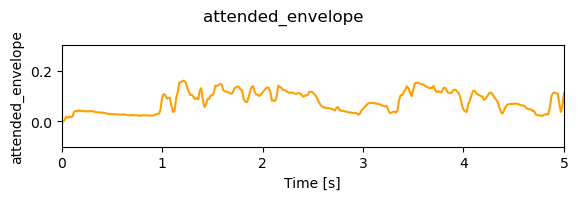

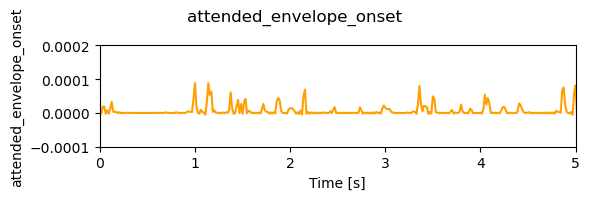

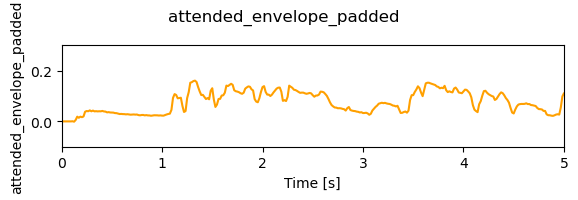

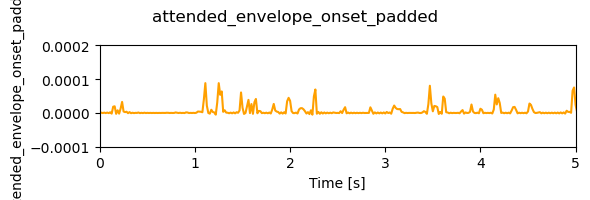

In [12]:
# SANITY CHECK: Plot envelope and onset for one subject
subject = SUBJECTS[0]
dst_dir = MAT_FILE_CONCAT_DIR / subject

for padded in [False, True]:
    env_name   = helper_functions.get_predictor_name(PREDICTOR_TYPE.ENVELOPE,       ATTENTION_TYPE.ATTENDED, padded)
    onset_name = helper_functions.get_predictor_name(PREDICTOR_TYPE.ENVELOPE_ONSET, ATTENTION_TYPE.ATTENDED, padded)

    envelope = eelbrain.load.unpickle(dst_dir / f"{env_name}_concat.pickle")
    onset    = eelbrain.load.unpickle(dst_dir / f"{onset_name}_concat.pickle")

    print(f"padded={padded}:", envelope, onset)
    eelbrain.plot.UTS([[envelope]], xlim=5, w=6, h=2, title=env_name)
    eelbrain.plot.UTS([[onset]],   xlim=5, w=6, h=2, title=onset_name)